# Source Tutorial

This tutorial covers the **Source** classes in `rompy-xbeach`, which provide
a unified interface for loading data from various file formats and sources.

## What You'll Learn

1. Understanding the source abstraction
2. Loading data from NetCDF files (`SourceCRSFile`)
3. Loading data from Intake catalogs (`SourceCRSIntake`)
4. Using in-memory xarray datasets (`SourceCRSDataset`)
5. Loading GeoTIFF files (`SourceGeotiff`)
6. Loading XYZ point cloud data (`SourceXYZ`)

## Prerequisites

- Basic understanding of xarray and coordinate reference systems (CRS)

In [1]:
import warnings
warnings.filterwarnings("ignore")

---
## 1. The Source Abstraction

Source objects in rompy-xbeach extend the [core sources](https://github.com/rom-py/rompy/blob/main/rompy/core/source.py)
from rompy with **CRS support**. The key requirement is that the `_open()` method
returns an xarray Dataset with:
- The `rio` accessor available (via rioxarray)
- The `crs` attribute set

This ensures all data has consistent spatial reference information for
interpolation onto the XBeach grid.

### Available Source Types

| Source Class | Use Case |
|--------------|----------|
| `SourceCRSFile` | NetCDF, Zarr, or other xarray-compatible files |
| `SourceCRSIntake` | Data from Intake catalogs |
| `SourceCRSDataset` | In-memory xarray Dataset objects |
| `SourceGeotiff` | GeoTIFF raster files (CRS auto-detected) |
| `SourceXYZ` | XYZ point cloud / CSV files |

---
## 2. SourceCRSFile

Load data from any file format supported by xarray (NetCDF, Zarr, etc.).
You must specify the CRS since NetCDF files typically don't embed it.

In [2]:
from pathlib import Path

# Change the data directory to the location in your computer where rompy-xbeach is cloned into
DATADIR = Path("../../../../rompy-xbeach/tests/data")

In [3]:
from rompy_xbeach.source import SourceCRSFile

source = SourceCRSFile(
    uri=DATADIR / "bathy.nc",
    kwargs=dict(engine="netcdf4"),  # xarray.open_dataset kwargs
    crs="EPSG:4326",                # Coordinate reference system
    x_dim="x",                      # Name of x dimension
    y_dim="y",                      # Name of y dimension
)

# Open the dataset
ds = source._open()
ds

<xarray.Dataset> Size: 130kB
Dimensions:  (y: 180, x: 176)
Coordinates:
  * y        (y) float64 1kB -32.65 -32.65 -32.65 ... -32.61 -32.61 -32.61
  * x        (x) float64 1kB 115.6 115.6 115.6 115.6 ... 115.6 115.6 115.6 115.6
Data variables:
    depth    (y, x) float32 127kB ...

In [4]:
# Verify CRS is set
print(f"CRS: {source.crs}")

CRS: EPSG:4326


### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `uri` | Path to the file |
| `kwargs` | Arguments passed to `xarray.open_dataset()` |
| `crs` | Coordinate reference system (EPSG code or WKT) |
| `x_dim`, `y_dim` | Names of the spatial dimensions |

---
## 3. SourceCRSIntake

Load data from an [Intake](https://intake.readthedocs.io/) catalog.
Useful for managing multiple datasets with metadata.

In [5]:
from rompy_xbeach.source import SourceCRSIntake

source = SourceCRSIntake(
    catalog_uri=DATADIR / "catalog.yaml",
    dataset_id="bathy_netcdf",
    crs="EPSG:4326",
)

ds = source._open()
print(f"Loaded dataset with variables: {list(ds.data_vars)}")

Loaded dataset with variables: ['depth']


### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `catalog_uri` | Path to the Intake catalog YAML file |
| `dataset_id` | ID of the dataset in the catalog |
| `crs` | Coordinate reference system |

---
## 4. SourceCRSDataset

Use an existing xarray Dataset object. Useful when you've already loaded
and processed data in memory.

In [6]:
from rompy_xbeach.source import SourceCRSDataset

# Use the dataset we loaded earlier
source = SourceCRSDataset(
    obj=ds,
    crs="EPSG:4326",
)

ds_from_source = source._open()
print(f"CRS: {source.crs}")

CRS: EPSG:4326


### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `obj` | xarray Dataset object |
| `crs` | Coordinate reference system |

---
## 5. SourceGeotiff

Load GeoTIFF raster files. The CRS is automatically extracted from the
file metadata, so you don't need to specify it.

In [7]:
from rompy_xbeach.source import SourceGeotiff

source = SourceGeotiff(
    filename=DATADIR / "bathy.tif",
)
source

SourceGeotiff(model_type='geotiff', filename=PosixPath('../../../../rompy-xbeach/tests/data/bathy.tif'), band=1, kwargs={})

In [8]:
ds = source._open()
print(f"Shape: {ds.data.shape}")
print(f"CRS: {ds.rio.crs}")

Shape: (180, 176)
CRS: EPSG:4326


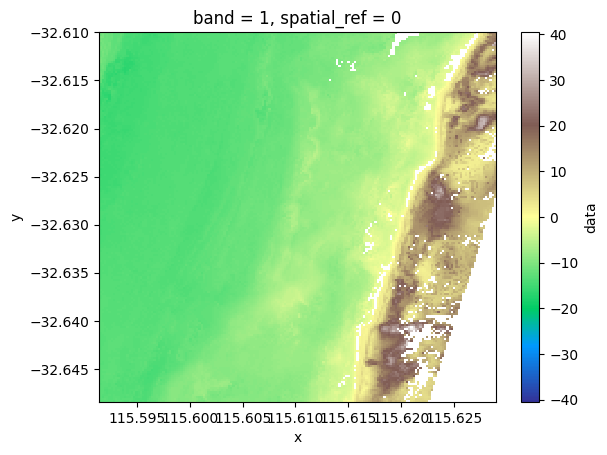

In [9]:
# Visualise the data
ds.data.plot(cmap="terrain")

### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `filename` | Path to the GeoTIFF file |

**Note**: CRS is automatically read from the GeoTIFF metadata.

---
## 6. SourceXYZ

Load XYZ point cloud data (e.g., from survey files or LiDAR exports).
The data is interpolated onto a regular grid during loading.

In [10]:
from rompy_xbeach.source import SourceXYZ

source = SourceXYZ(
    filename=DATADIR / "bathy_xyz.zip",
    res=0.0005,                              # Grid resolution (in CRS units)
    xcol="easting",                          # Column name for x coordinates
    ycol="northing",                         # Column name for y coordinates
    zcol="elevation",                        # Column name for z values
    crs="EPSG:4326",                         # Coordinate reference system
    read_csv_kwargs=dict(sep="\t"),          # pandas.read_csv kwargs
    griddata_kwargs=dict(method="linear"),   # scipy.griddata kwargs
)
source

SourceXYZ(model_type='xyz', filename=PosixPath('../../../../rompy-xbeach/tests/data/bathy_xyz.zip'), crs='EPSG:4326', res=0.0005, xcol='easting', ycol='northing', zcol='elevation', read_csv_kwargs={'sep': '\t'}, griddata_kwargs={'method': 'linear'})

In [11]:
ds = source._open()
ds

2026-01-10 18:35:07 [INFO] rompy_xbeach.source : Interpolating onto a grid of shape (78, 76)


<xarray.Dataset> Size: 49kB
Dimensions:      (y: 78, x: 76)
Coordinates:
  * y            (y) float64 624B -32.65 -32.65 -32.65 ... -32.61 -32.61 -32.61
  * x            (x) float64 608B 115.6 115.6 115.6 115.6 ... 115.6 115.6 115.6
    spatial_ref  int64 8B 0
Data variables:
    data         (y, x) float64 47kB -13.21 -13.19 -13.28 -13.17 ... nan nan nan

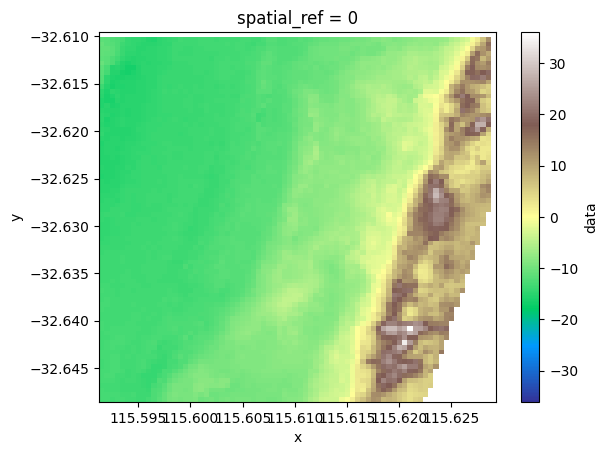

In [12]:
# Visualise the interpolated grid
ds.data.plot(cmap="terrain")

### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `filename` | Path to the XYZ file (supports .zip) |
| `res` | Output grid resolution |
| `xcol`, `ycol`, `zcol` | Column names in the file |
| `crs` | Coordinate reference system |
| `read_csv_kwargs` | Arguments for `pandas.read_csv()` |
| `griddata_kwargs` | Arguments for `scipy.interpolate.griddata()` |

---
## 7. Summary

### Choosing a Source Type

| Data Format | Source Class |
|-------------|--------------|
| NetCDF / Zarr | `SourceCRSFile` |
| Intake catalog | `SourceCRSIntake` |
| In-memory xarray | `SourceCRSDataset` |
| GeoTIFF | `SourceGeotiff` |
| XYZ / CSV point cloud | `SourceXYZ` |

### Common Pattern

All source types follow the same pattern:

```python
# 1. Create the source
source = SourceGeotiff(filename="bathy.tif")

# 2. Use with a data class
bathy = XBeachBathy(source=source, ...)

# 3. Generate files
bathy.get(destdir=destdir, grid=grid)
```

### Next Steps

- See the **Bathymetry Tutorial** for using sources with `XBeachBathy`
- See the **Wave Boundary Tutorial** for using sources with wave data
- See the **Forcing Tutorial** for using sources with wind/tide data